In [2]:
import os
import scipy
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train_path = "Pipeline Corrosion Detection Dataset/train"
test_path = "Pipeline Corrosion Detection Dataset/test"

In [4]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

In [5]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 960 images belonging to 2 classes.
Found 240 images belonging to 2 classes.


(-0.5, 439.5, 239.5, -0.5)

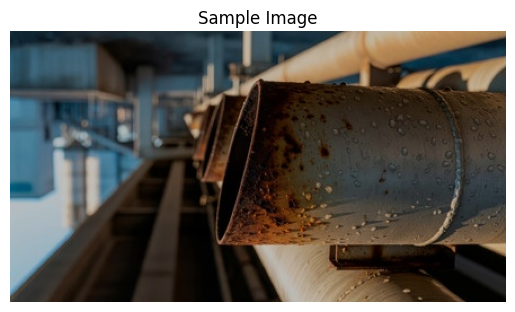

In [6]:
img_path = train_path + "/corroded/" + os.listdir(train_path + "/corroded")[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")

In [7]:
print(train_data.class_indices)

{'corroded': 0, 'normal': 1}


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False)

# ❗ FREEZE base model (VERY IMPORTANT)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)   # prevents overfitting
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 Conv1 (Conv2D)                 (None, None, None,   864         ['input_1[0][0]']                
                                32)                                                               
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, None, None,   128         ['Conv1[0][0]']                  
                                32)                                                           

In [10]:
import sys
!{sys.executable} -m pip install pillow


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from PIL import Image
print("PIL working")

PIL working


In [19]:
import sys
!{sys.executable} -m pip install scipy==1.9.3

     ---------------------------------------- 40.1/40.1 MB 4.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Viren\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~cipy.libs\\libscipy_openblas-f07f5a5d207a3a47104dca54d6d0c86a.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
history = model.fit(train_data,validation_data=test_data,epochs=10)

Epoch 1/10
60/60 [==============================] - 59s 904ms/step - loss: 0.7609 - accuracy: 0.5875 - val_loss: 0.4389 - val_accuracy: 0.8583
Epoch 2/10
60/60 [==============================] - 47s 780ms/step - loss: 0.4322 - accuracy: 0.8010 - val_loss: 0.2668 - val_accuracy: 0.9292
Epoch 3/10
60/60 [==============================] - 44s 729ms/step - loss: 0.3073 - accuracy: 0.8865 - val_loss: 0.1716 - val_accuracy: 0.9792
Epoch 4/10
60/60 [==============================] - 42s 697ms/step - loss: 0.2249 - accuracy: 0.9219 - val_loss: 0.1226 - val_accuracy: 0.9833
Epoch 5/10
60/60 [==============================] - 43s 710ms/step - loss: 0.1864 - accuracy: 0.9406 - val_loss: 0.0930 - val_accuracy: 0.9958
Epoch 6/10
60/60 [==============================] - 49s 812ms/step - loss: 0.1590 - accuracy: 0.9490 - val_loss: 0.0741 - val_accuracy: 0.9958
Epoch 7/10
60/60 [==============================] - 51s 839ms/step - loss: 0.1112 - accuracy: 0.9729 - val_loss: 0.0548 - val_accuracy: 0.9958

In [13]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

15/15 [==============================] - 6s 371ms/step - loss: 0.0280 - accuracy: 1.0000
Test Accuracy: 1.0


In [21]:
from tensorflow.keras.preprocessing import image

img_path = "Pipeline Corrosion Detection Dataset/test/corroded/i3.jpg_aug4.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]

if pred > 0.5:
    print("Normal")
else:
    print("Corroded")

1/1 [==============================] - 0s 71ms/step
Corroded


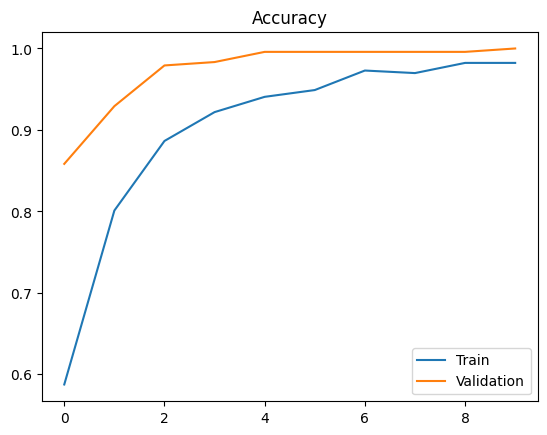

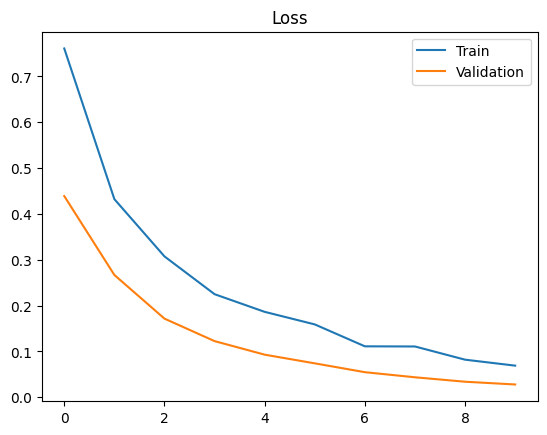

In [22]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.show()

In [24]:
model.save("corrosion_model.h5")
print("Model Saved!")

Model Saved!


Using layer: expanded_conv_project_BN


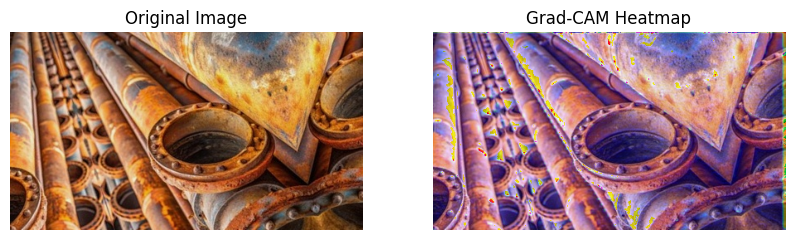

In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load model
model = load_model("corrosion_model.h5")

# Image path
img_path = r"C:\Pipeline Corrosion Detection Model\dl-project\Pipeline Corrosion Detection Dataset\test\corroded\i27.jpg_aug6.jpg"   # change this

# Preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Get last convolution layer
last_conv_layer = None
for layer in reversed(model.layers):
    if "conv" in layer.name:
        last_conv_layer = layer.name
        break

print("Using layer:", last_conv_layer)

# Create Grad-CAM model
grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

# Compute gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

# Pool gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Multiply gradients with feature maps
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize heatmap
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Resize heatmap
img_original = cv2.imread(img_path)
heatmap = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))

# Convert to color
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay heatmap
superimposed_img = heatmap * 0.4 + img_original

# Show results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

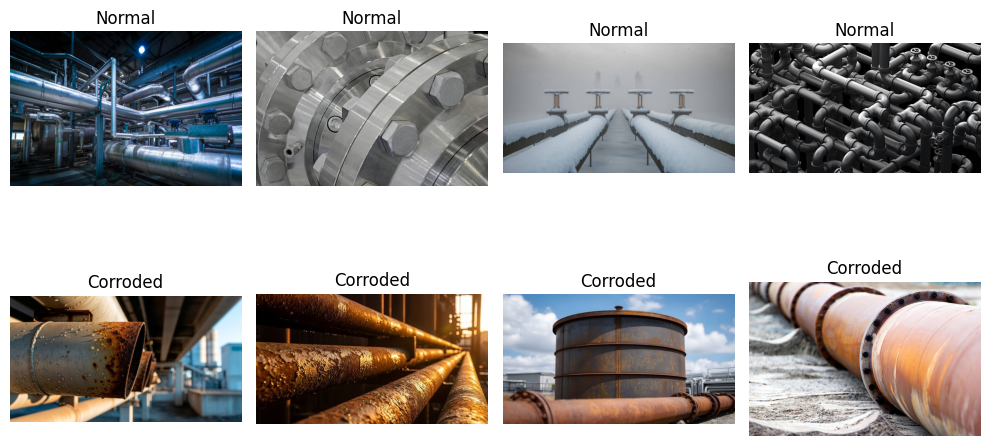

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

# Paths (change these according to your dataset)
normal_path = r"Pipeline Corrosion Detection/train/normal"
corroded_path = r"Pipeline Corrosion Detection/train/corroded"

# Function to load images
def load_images(folder, num=4):
    images = []
    filenames = os.listdir(folder)[:num]
    
    for file in filenames:
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    
    return images

# Load images
normal_images = load_images(normal_path, 4)
corroded_images = load_images(corroded_path, 4)

# Plot images
plt.figure(figsize=(10, 6))

# Normal images
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(normal_images[i])
    plt.title("Normal")
    plt.axis("off")

# Corroded images
for i in range(4):
    plt.subplot(2, 4, i+5)
    plt.imshow(corroded_images[i])
    plt.title("Corroded")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import os
print(os.listdir(normal_path)[:20])

['i1.jpg', 'i10.jpg', 'i11.jpg', 'i12.jpg', 'i13.jpg', 'i14.jpg', 'i15.jpg', 'i16.jpg', 'i17.jpg', 'i18.jpg', 'i19.jpg', 'i2.jpg', 'i20.jpg', 'i21.jpg', 'i22.jpg', 'i23.jpg', 'i24.jpg', 'i25.jpg', 'i26.jpg', 'i27.jpg']


In [6]:
import os
import cv2
import matplotlib.pyplot as plt

# Correct dataset path
normal_path = r"Pipeline Corrosion Detection/train/normal"
corroded_path = r"Pipeline Corrosion Detection/train/corroded"

normal_files = ["i39.jpg", "i47.jpg", "i59.jpg", "i60.jpg"]
corroded_files = ["i46.jpg", "i48.jpg", "i54.jpg", "i56.jpg"]

def read_img(folder, filename):
    path = os.path.join(folder, filename)

    print("Reading:", path)   # check path

    img = cv2.imread(path)

    if img is None:
        print("Image not found:", path)
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (220,220))
    return img

plt.figure(figsize=(12,7))

# Normal Images
for i in range(4):
    img = read_img(normal_path, normal_files[i])
    if img is not None:
        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title("Normal")
        plt.axis("off")

# Corroded Images
for i in range(4):
    img = read_img(corroded_path, corroded_files[i])
    if img is not None:
        plt.subplot(2,4,i+5)
        plt.imshow(img)
        plt.title("Corroded")
        plt.axis("off")

plt.tight_layout()
plt.show()

Reading: Pipeline Corrosion Detection/train/normal\i39.jpg
Image not found: Pipeline Corrosion Detection/train/normal\i39.jpg
Reading: Pipeline Corrosion Detection/train/normal\i47.jpg
Image not found: Pipeline Corrosion Detection/train/normal\i47.jpg
Reading: Pipeline Corrosion Detection/train/normal\i59.jpg
Image not found: Pipeline Corrosion Detection/train/normal\i59.jpg
Reading: Pipeline Corrosion Detection/train/normal\i60.jpg
Image not found: Pipeline Corrosion Detection/train/normal\i60.jpg
Reading: Pipeline Corrosion Detection/train/corroded\i46.jpg
Image not found: Pipeline Corrosion Detection/train/corroded\i46.jpg
Reading: Pipeline Corrosion Detection/train/corroded\i48.jpg
Image not found: Pipeline Corrosion Detection/train/corroded\i48.jpg
Reading: Pipeline Corrosion Detection/train/corroded\i54.jpg
Image not found: Pipeline Corrosion Detection/train/corroded\i54.jpg
Reading: Pipeline Corrosion Detection/train/corroded\i56.jpg
Image not found: Pipeline Corrosion Detection

<Figure size 1200x700 with 0 Axes>

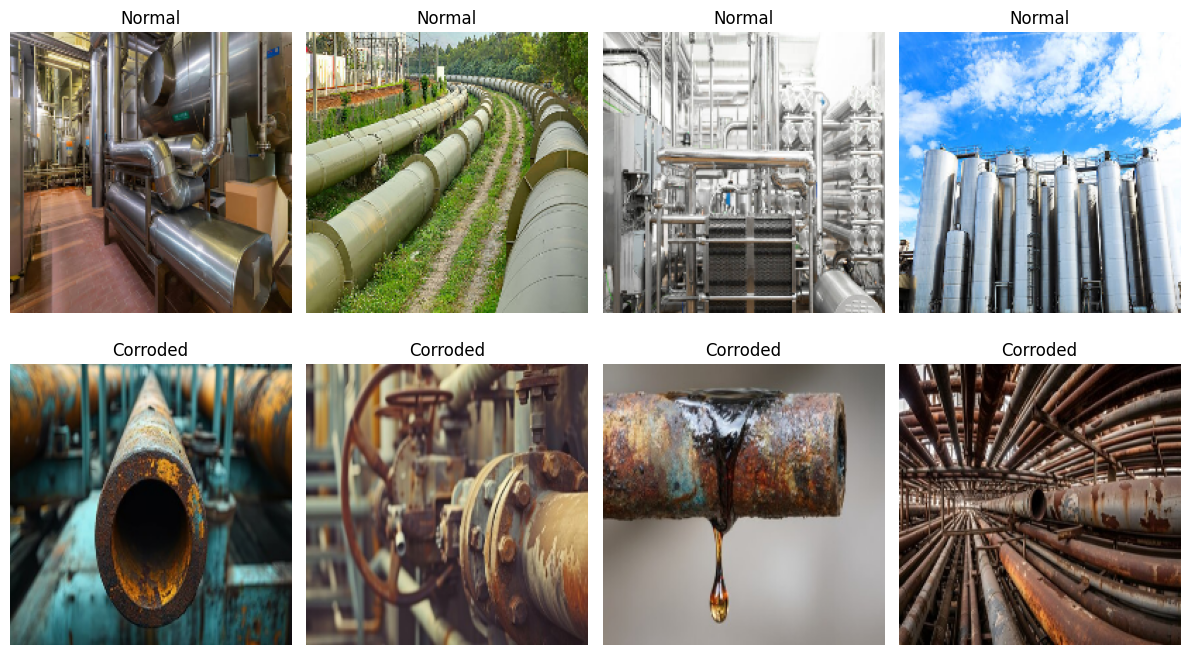

In [13]:
import cv2
import matplotlib.pyplot as plt

# Full image paths
normal_images = [
    r"Pipeline Corrosion Detection/test/normal/i39.jpg",
    r"Pipeline Corrosion Detection/test/normal/i47.jpg",
    r"Pipeline Corrosion Detection/test/normal/i59.jpg",
    r"Pipeline Corrosion Detection/test/normal/i60.jpg"
]

corroded_images = [
    r"Pipeline Corrosion Detection/test/corroded/i46.jpg",
    r"Pipeline Corrosion Detection/test/corroded/i48.jpg",
    r"Pipeline Corrosion Detection/test/corroded/i54.jpg",
    r"Pipeline Corrosion Detection/test/corroded/i56.jpg"
]

def read_img(path):
    img = cv2.imread(path)

    if img is None:
        print("Image not found:", path)
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (200,200))
    return img

plt.figure(figsize=(12,7))

# Normal images
for i in range(4):
    img = read_img(normal_images[i])
    if img is not None:
        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title("Normal")
        plt.axis("off")

# Corroded images
for i in range(4):
    img = read_img(corroded_images[i])
    if img is not None:
        plt.subplot(2,4,i+5)
        plt.imshow(img)
        plt.title("Corroded")
        plt.axis("off")

plt.tight_layout()
plt.show()

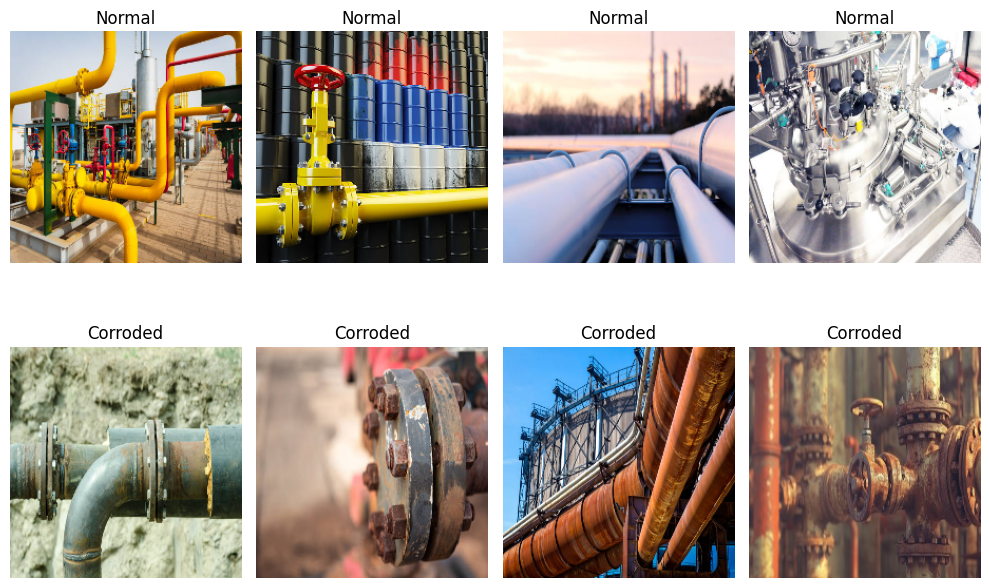

In [12]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Dataset folders
normal_path = r"Pipeline Corrosion Detection/train/normal"
corroded_path = r"Pipeline Corrosion Detection/train/corroded"

# Randomly choose 4 images
normal_files = random.sample(os.listdir(normal_path), 4)
corroded_files = random.sample(os.listdir(corroded_path), 4)

def read_img(folder, filename):
    path = os.path.join(folder, filename)

    img = cv2.imread(path)

    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Same size for all images
    img = cv2.resize(img, (220,220))

    return img

# Display
plt.figure(figsize=(10,7))

# Normal
for i in range(4):
    img = read_img(normal_path, normal_files[i])
    if img is not None:
        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title("Normal")
        plt.axis("off")

# Corroded
for i in range(4):
    img = read_img(corroded_path, corroded_files[i])
    if img is not None:
        plt.subplot(2,4,i+5)
        plt.imshow(img)
        plt.title("Corroded")
        plt.axis("off")

plt.tight_layout()
plt.show()